<a href="https://colab.research.google.com/github/Devii16/cv-labs/blob/main/CV7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

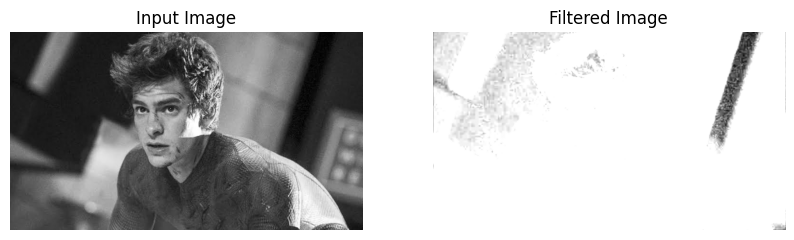

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


image = cv2.imread("/content/AG.jpg", cv2.IMREAD_GRAYSCALE)


if image is None:
    print("Image not found")
    exit()


kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])


p = 1
s = 1


H, W = image.shape
KH, KW = kernel.shape


if p != 0:
    padded_image = np.pad(
        image,
        ((p, p), (p, p)),
        mode='constant',
        constant_values=0
    )
else:
    padded_image = image


H_out = ((H - KH + 2 * p) // s) + 1
W_out = ((W - KW + 2 * p) // s) + 1


output = np.zeros((H_out, W_out), dtype=np.float32)


for i in range(H_out):
    for j in range(W_out):

        sum_value = 0


        for m in range(KH):
            for n in range(KW):

                image_pixel = padded_image[
                    i * s + m,
                    j * s + n
                ]

                kernel_pixel = kernel[m, n]

                sum_value += image_pixel * kernel_pixel


        output[i, j] = sum_value


output = np.clip(output, 0, 255).astype(np.uint8)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(output, cmap='gray')
plt.title("Filtered Image")
plt.axis("off")

plt.show()


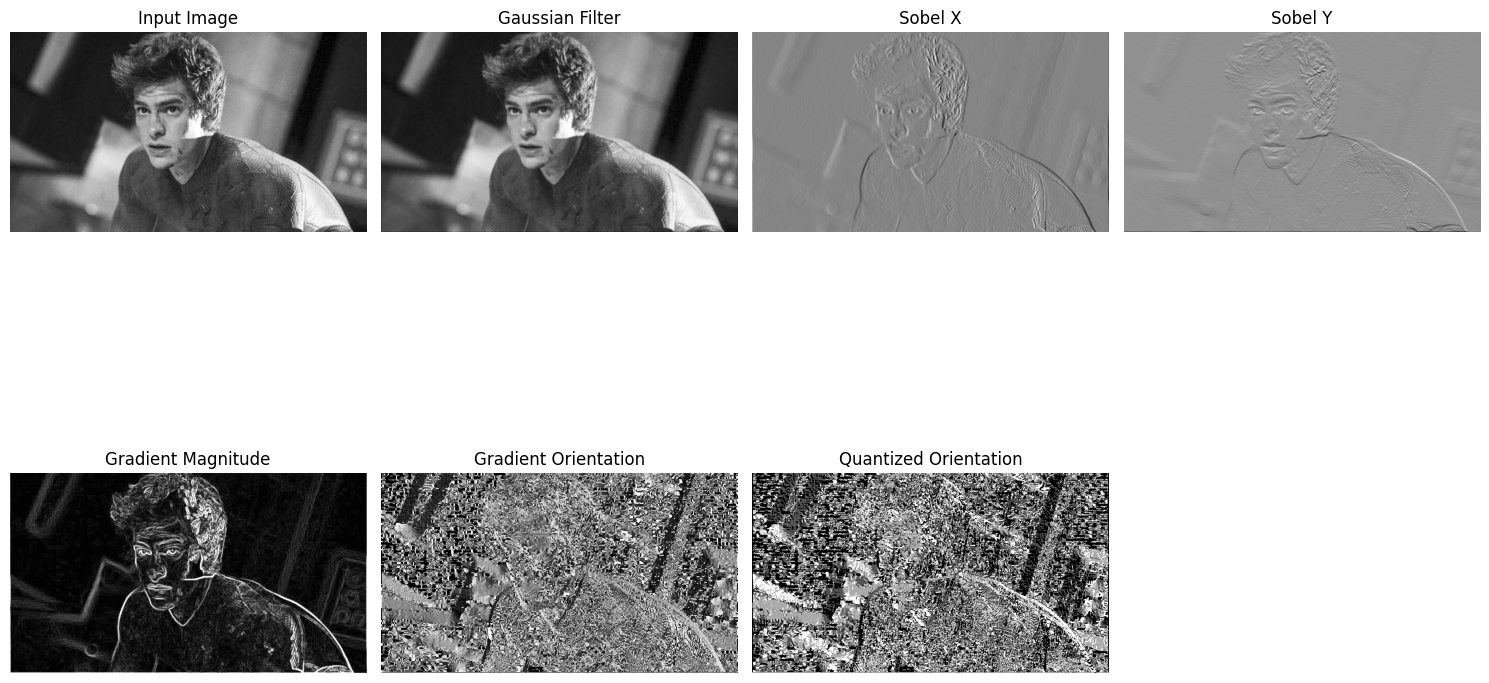

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("/content/AG.jpg", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image not found")
    exit()



gaussian_kernel = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32)

gaussian_kernel = gaussian_kernel / 16

p = 1
s = 1

H, W = image.shape
KH, KW = gaussian_kernel.shape

padded_image = np.pad(
    image,
    ((p, p), (p, p)),
    mode='constant',
    constant_values=0
)

H_out = ((H - KH + 2 * p) // s) + 1
W_out = ((W - KW + 2 * p) // s) + 1

gaussian_output = np.zeros((H_out, W_out), dtype=np.float32)

for i in range(H_out):
    for j in range(W_out):

        sum_value = 0

        for m in range(KH):
            for n in range(KW):

                image_pixel = padded_image[
                    i * s + m,
                    j * s + n
                ]

                kernel_pixel = gaussian_kernel[m, n]

                sum_value += image_pixel * kernel_pixel

        gaussian_output[i, j] = sum_value

gaussian_output = np.clip(
    gaussian_output, 0, 255
).astype(np.uint8)




sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

padded_gaussian = np.pad(
    gaussian_output,
    ((1, 1), (1, 1)),
    mode='constant',
    constant_values=0
)

sobel_x = np.zeros((H, W), dtype=np.float32)

for i in range(H):
    for j in range(W):

        sum_value = 0

        for m in range(3):
            for n in range(3):

                sum_value += (
                    padded_gaussian[i + m, j + n]
                    * sobel_x_kernel[m, n]
                )

        sobel_x[i, j] = sum_value




sobel_y_kernel = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=np.float32)

sobel_y = np.zeros((H, W), dtype=np.float32)

for i in range(H):
    for j in range(W):

        sum_value = 0

        for m in range(3):
            for n in range(3):

                sum_value += (
                    padded_gaussian[i + m, j + n]
                    * sobel_y_kernel[m, n]
                )

        sobel_y[i, j] = sum_value




magnitude = np.sqrt(
    sobel_x ** 2 + sobel_y ** 2
)

magnitude = np.clip(
    magnitude, 0, 255
).astype(np.uint8)




orientation = np.arctan2(
    sobel_y,
    sobel_x
)

orientation = np.degrees(orientation)


orientation[orientation < 0] += 180




quantized_orientation = np.zeros_like(orientation)

for i in range(H):
    for j in range(W):

        angle = orientation[i, j]

        if (angle >= 0 and angle < 22.5) or \
           (angle >= 157.5 and angle <= 180):

            quantized_orientation[i, j] = 0

        elif angle >= 22.5 and angle < 67.5:

            quantized_orientation[i, j] = 45

        elif angle >= 67.5 and angle < 112.5:

            quantized_orientation[i, j] = 90

        elif angle >= 112.5 and angle < 157.5:

            quantized_orientation[i, j] = 135

plt.figure(figsize=(15, 10))

plt.subplot(2, 4, 1)
plt.imshow(image, cmap='gray')
plt.title("Input Image")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(gaussian_output, cmap='gray')
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(sobel_x, cmap='gray')
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(sobel_y, cmap='gray')
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(magnitude, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(orientation, cmap='gray')
plt.title("Gradient Orientation")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(quantized_orientation, cmap='gray')
plt.title("Quantized Orientation")
plt.axis("off")

plt.tight_layout()
plt.show()